In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [3]:
cognac = pd.read_csv('cognac.csv')

In [9]:
print(cognac.tail(10))
cognac.info()

     Alcohol  Malic_Acid   Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
168    13.58        2.58  2.69          24.5        105           1.55   
169    13.40        4.60  2.86          25.0        112           1.98   
170    12.20        3.03  2.32          19.0         96           1.25   
171    12.77        2.39  2.28          19.5         86           1.39   
172    14.16        2.51  2.48          20.0         91           1.68   
173    13.71        5.65  2.45          20.5         95           1.68   
174    13.40        3.91  2.48          23.0        102           1.80   
175    13.27        4.28  2.26          20.0        120           1.59   
176    13.17        2.59  2.37          20.0        120           1.65   
177    14.13        4.10  2.74          24.5         96           2.05   

     Flavanoids  Nonflavanoid_Phenols  Proanthocyanins  Color_Intensity   Hue  \
168        0.84                  0.39             1.54         8.660000  0.74   
169        0.96        

In [39]:
cognac.isnull().sum()
cognac.describe()

scaler = StandardScaler()
scaled_features = scaler.fit_transform(cognac)

best_k = 2
best_score = -1
max_k = min(10, len(scaled_features) - 1)

for k in range(2, max_k+1):
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels_test = kmeans_test.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, labels_test)

    if score > best_score:
        best_score = score
        best_k = k

print(f"Optimal number of clusters (k) determined: {best_k}")
print(f"Highest Silhouette Score achieved: {best_score:.4f}\n") 

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init='auto')
final_labels = kmeans_final.fit_predict(scaled_features)

cognac['Cluster_Label'] = final_labels
print("--- Identified Cluster Labels for Cognac Records ---")
print(cognac)

Optimal number of clusters (k) determined: 3
Highest Silhouette Score achieved: 0.3322

--- Identified Cluster Labels for Cognac Records ---
     Alcohol  Malic_Acid   Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
0      14.23        1.71  2.43          15.6        127           2.80   
1      13.20        1.78  2.14          11.2        100           2.65   
2      13.16        2.36  2.67          18.6        101           2.80   
3      14.37        1.95  2.50          16.8        113           3.85   
4      13.24        2.59  2.87          21.0        118           2.80   
..       ...         ...   ...           ...        ...            ...   
173    13.71        5.65  2.45          20.5         95           1.68   
174    13.40        3.91  2.48          23.0        102           1.80   
175    13.27        4.28  2.26          20.0        120           1.59   
176    13.17        2.59  2.37          20.0        120           1.65   
177    14.13        4.10  2.74          24.5 

C:\Users\narer\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\narer\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\narer\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\narer\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

In [37]:
cognac['Cluster_Label'].value_counts()

Cluster_Label
0    65
2    62
1    51
Name: count, dtype: int64

In [45]:
pca = PCA(n_components=2)
pca_transformed = pca.fit_transform(scaled_features)

print("--- Dimensionality Comparison ---")
print(f"Original dataset dimensions: {scaled_features.shape}")
print(f"PCA-transformed dataset dimensions: {pca_transformed.shape}\n")

print("--- PCA Components & Variance ---")
print("Principal Components (Eigenvectors showing how original features combine):")
print(pca.components_)
print("\nExplained Variance Ratio (How much information each PC retains):")
print(pca.explained_variance_ratio_)
print(f"Total Information Retained: {sum(pca.explained_variance_ratio_) * 100:.2f}%\n")

--- Dimensionality Comparison ---
Original dataset dimensions: (178, 14)
PCA-transformed dataset dimensions: (178, 2)

--- PCA Components & Variance ---
Principal Components (Eigenvectors showing how original features combine):
[[ 0.20136527 -0.20551275  0.0367749  -0.23597954  0.17078962  0.38190424
   0.40315938 -0.27968823  0.29605262 -0.02282749  0.25135628  0.3409569
   0.32530406  0.26640627]
 [ 0.40653818  0.256898    0.27731389  0.02632127  0.22693954 -0.04172852
  -0.1018012   0.09883551 -0.06055851  0.47999975 -0.30792195 -0.22726666
   0.27519388  0.40186407]]

Explained Variance Ratio (How much information each PC retains):
[0.35514167 0.21563466]
Total Information Retained: 57.08%



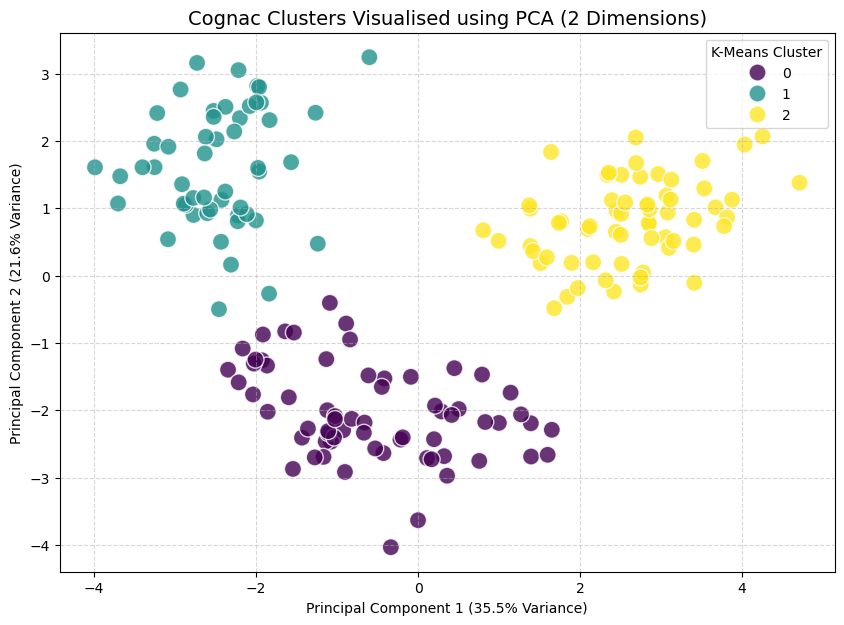

In [55]:
pca_df = pd.DataFrame(data=pca_transformed, columns=['PC1', 'PC2'])
pca_df['Cluster'] = cognac['Cluster_Label'] 

# Plotting
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='Cluster', 
    data=pca_df, 
    palette='viridis', 
    s=150,             
    alpha=0.8          
)

# Add titles and labels
plt.title('Cognac Clusters Visualised using PCA (2 Dimensions)', fontsize=14)
plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)")
plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)")
plt.legend(title='K-Means Cluster')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()